In [9]:
req.libs <- c("BuenRTools", "dplyr", "data.table", "ggplot2", "scattermore", "future.apply", "stringi", "zellkonverter", "SingleCellExperiment")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"              "base"                

[[2]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"              "base"                

[[3]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"              "base"                

[[4]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"              "base"                

[[5]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"              "base"                

[[6]]
 [1] "zellkonverter"        "stringi"              "future.apply"        
 [4] "future"               "scattermore"          "data.table"          
 [7] "dplyr"                "BuenRTools"           "ggplot2"             
[10] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
[13] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[16] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[19] "matrixStats"          "Matrix"               "stats"               
[22] "graphics"             "grDevices"            "utils"               
[25] "datasets"             "methods"

In [5]:
myPeakBedFile <- "/fab/AlignedData/rsav_minimorf/splitting_fragments/clean_peaks/cleanpeaks.bed"
meta.df <- fread("/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.csv")
peakRanges <- chromVAR::getPeaks(filename = myPeakBedFile,sort_peaks = FALSE)
atac.dir <- "/fab/AlignedData/rsav_minimorf/igvf_pipeline/"
frag_files <- list.files(
  path = atac.dir,
  pattern = ".fragments.tsv.gz$",  # regex for exact match
  recursive = TRUE,                         # search subdirectories
  full.names = TRUE                         # return full paths
)

In [ ]:
outdir <- "/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/sublibrary_peak_SE/"

In [ ]:
lapply(frag_files, function(x){
    se <- BuenRTools::getCountsFromFrags(fragFile=x,
                                           peaks=peakRanges, 
                                           barcodeList = meta.df$barcode)
    filename <- stri_split_fixed(basename(x), pattern = "-SS-V1", simplify = TRUE)[,1]
    saveRDS(se, paste0(outdir, filename, ".atacSE.rds"))
    message("finished ", filename, " ", Sys.time())
    return(message("finished ", filename, " ", Sys.time()))
})

In [ ]:
se.list <- pbmclapply(input.files, readRDS, mc.cores = 12)
all.se <- do.call(cbind, se.list)
saveRDS(all.se, "/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/atac.se.rds")

In [1]:
all.se <- readRDS("/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/atac.se.rds")

In [7]:
meta.dedub.df <- fread("/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.dedoublet.csv")
dim(all.se)
dim(meta.dedub.df)

all.se <- all.se[,meta.dedub.df$barcode]
dim(all.se)

[1] 345953 762374

[1] 702314     11

[1] 345953 702314

In [11]:
atac.mx <- all.se@assays@data$counts

peak.ids <- data.frame(rowRanges(all.se))
peak.ids$fullname <- paste0(peak.ids$seqnames, "_", peak.ids$start, "_", peak.ids$end)
rownames(atac.mx) <- peak.ids$fullname

atac.sce <- SingleCellExperiment(assays = list(counts = atac.mx))
writeH5AD(atac.sce, file = "/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/full_atac_dedup.h5ad")

ℹ Using the 'counts' assay as the X matrix



In [13]:
saveRDS(all.se, "/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/atac.se.dedoublet.rds")

In [ ]:
matrices <- lapply(se.list, function(x){
return(x@assays@data$counts)
})

peak.ids <- data.frame(rowRanges(se.list[[1]]))
peak.ids$fullname <- paste0(peak.ids$seqnames, "_", peak.ids$start, "_", peak.ids$end)

matrices <- lapply(matrices, function(x){
rownames(x) <- peak.ids$fullname
return(x)
})

library(SingleCellExperiment)

matrices <- lapply(matrices, function(x){
return(SingleCellExperiment(assays = list(counts = x)))
})

lapply(matrices, function(x){
name <- stri_split_fixed(colnames(x)[1], pattern = "_", simplify = TRUE)[,2]
filename <- paste0("/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/sublibrary_peak_h5ads/", name, ".h5ad")
writeH5AD(x, file = filename)
})



In [ ]:
asdf <- as.data.frame(all.se@colData)
rownames(asdf) <- NULL
fwrite(asdf, "/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/atac.se.meta.csv")

In [2]:
meta.atac.se <- fread("/mnt/users/rachelsavage/paper_minimorf/data/atac_matrices/atac.se.meta.csv")
all.meta <- fread("/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.csv")

In [6]:
colnames(meta.atac.se) <- c("barcode", "atacse_depth", "atacse_FRIP")
meta.atac.se <- meta.atac.se %>% left_join(all.meta)

Joining with `by = join_by(barcode)`


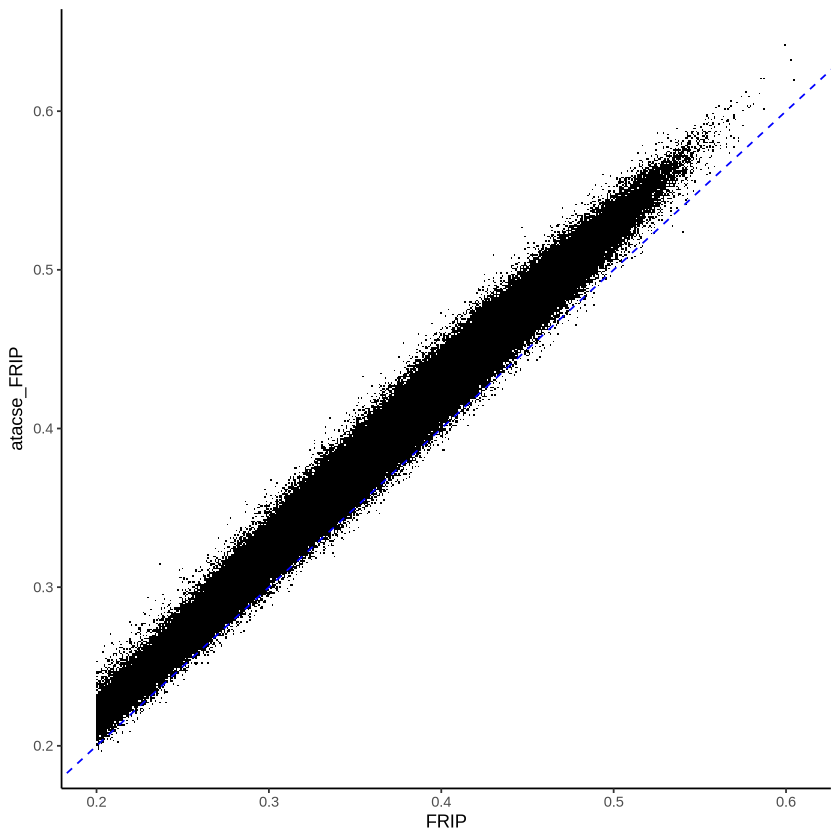

In [9]:
ggplot(meta.atac.se, aes(x=FRIP, y= atacse_FRIP))+
geom_scattermore()+
theme_classic()+
geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "blue")

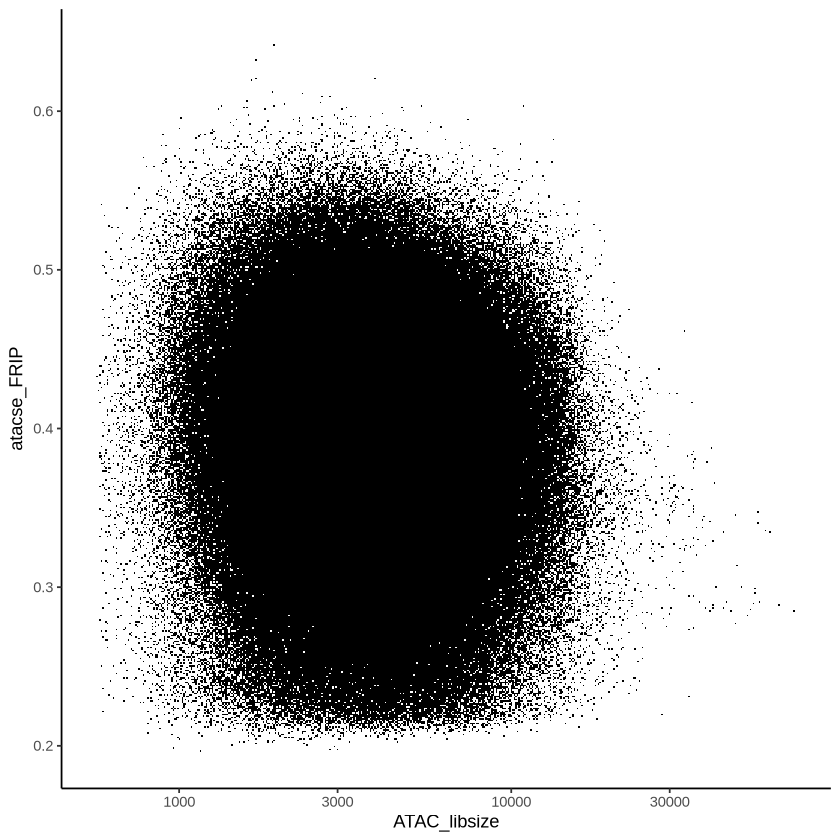

In [13]:
ggplot(meta.atac.se, aes(x=ATAC_libsize, y= atacse_FRIP))+
geom_scattermore()+
theme_classic()+
scale_x_continuous(trans = "log10")

In [10]:
head(meta.atac.se)

barcode,atacse_depth,atacse_FRIP,ATAC_total_mapped_reads,ATAC_unique_mapped_reads,ATAC_libsize,sublibrary,FRIP,condition,n.tfs,final.tf,donor
<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>
ACAGTGGTACAGTGGTGAGCCAAT_SS-PKR-608,735,0.4027211,973,735,1649,SS-PKR-608,0.3755102,a.acute_unstim,0,,donor1
ACAGTGGTACAGTGGTGTTAGCCT_SS-PKR-608,1742,0.3771527,2184,1742,4640,SS-PKR-608,0.3576349,a.acute_unstim,1,PAX2,donor1
ACAGTGGTACAGTGGTTTGGTATG_SS-PKR-608,1540,0.3818182,1980,1540,3767,SS-PKR-608,0.3662338,a.acute_unstim,0,,donor1
ACAGTGGTACTTGATGGTACATCT_SS-PKR-608,1375,0.2756364,1774,1375,3327,SS-PKR-608,0.2589091,a.acute_unstim,1,ASCL4,donor1
ACAGTGGTACTTGATGTTAGGCAT_SS-PKR-608,1378,0.3403483,1825,1378,3088,SS-PKR-608,0.3243832,a.acute_unstim,2,EN1+PAX9,donor2
ACAGTGGTATCACGTTTCATCCTA_SS-PKR-608,2339,0.2710560,3054,2339,5459,SS-PKR-608,0.2565199,a.acute_unstim,0,,donor2
